# Portfolio backtest demo

A full run against `config/example.yaml`: five US sector ETFs, weighted by inverse
volatility, rebalanced quarterly, measured against SPY from 2015 to 2024.

Every number below comes out of the library. There is no analysis code in this
notebook, so nothing here can disagree with what `pbt run` prints on the command
line.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

from pbt import montecarlo, plots
from pbt.cli import load_market_data
from pbt.config import load_config
from pbt.engine import run_backtest
from pbt.report import build_report, comparison_table, drawdown_episodes

# Works whether the notebook is run from the repo root or from notebooks/.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CACHE_DIR = ROOT / "data_cache"
OUTPUT_DIR = ROOT / "output"

pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

## 1. Configuration

The config is validated as it loads, so a mistyped key or a set of weights that does
not sum to one gets caught here rather than halfway through a run.

In [2]:
config = load_config(ROOT / "config" / "example.yaml")
config

Config(tickers=('XLK', 'XLF', 'XLE', 'XLV', 'XLU'), benchmark='SPY', start=datetime.date(2015, 1, 1), end=datetime.date(2024, 12, 31), initial_capital=100000.0, weighting='inverse_vol', rebalance='quarterly', risk_free_rate=0.02, transaction_cost_bps=5.0, custom_weights=None, lookback_days=63)

## 2. Prices

Downloads on the first run and reads from the parquet cache after that, keyed by
ticker and date range. Anything missing more than 10% of the window gets dropped, and
says so.

In [3]:
prices, benchmark = load_market_data(config, CACHE_DIR)
print(f"{len(prices):,} trading days, {prices.shape[1]} holdings, benchmark {config.benchmark}")
prices.tail(3)

2,516 trading days, 5 holdings, benchmark SPY


,XLK,XLF,XLE,XLV,XLU
date,,,,,
2024-12-27,117.7229,47.6679,40.3568,135.3921,36.4938
2024-12-30,116.2259,47.2084,40.3520,133.7259,36.3403
2024-12-31,115.2593,47.2573,40.8818,134.0474,36.3067


## 3. The backtest

Holdings drift with prices between rebalances, then get traded back to target at the
close of the last trading day of each quarter, paying a cost on the turnover.

Worth noting where the invested window starts. Inverse volatility spends its first 63
trading days building the opening volatility estimate, so the curve begins after that
rather than reaching back for data from before the configured start date.

In [4]:
result = run_backtest(prices, benchmark, config)
print(f"invested {result.index[0].date()} to {result.index[-1].date()}")
result.tail(3)

invested 2015-04-06 to 2024-12-31


,portfolio_value,portfolio_return,benchmark_value,benchmark_return,turnover,costs_paid
date,,,,,,
2024-12-27,"291,706.6385",-0.0051,"339,252.2407",-0.0105,0.0000,0.0000
2024-12-30,"289,429.2460",-0.0078,"335,380.8340",-0.0114,0.0000,0.0000
2024-12-31,"289,964.2892",0.0018,"334,160.7436",-0.0036,0.0000,0.0000


## 4. Metrics

The benchmark column runs the same functions with SPY as its own reference, which is
why its beta comes out at exactly 1.00 and its tracking error at zero. That doubles as
a check that nothing is wired up wrongly.

In [5]:
comparison = comparison_table(
    result["portfolio_return"], result["benchmark_return"], config.risk_free_rate
)
comparison

,Portfolio,Benchmark
CAGR,0.1156,0.1319
Annualised volatility,0.1708,0.1770
Sharpe ratio,0.6104,0.6773
Sortino ratio,0.8554,0.9409
Max drawdown,-0.3686,-0.3372
Calmar ratio,0.3137,0.3913
Beta vs benchmark,0.9107,1.0000
Jensen's alpha (annual),-0.0049,0.0000
Tracking error,0.0587,0.0000
Information ratio,-0.2661,NaN


### Drawdowns

The deepest peak-to-trough falls, with dates and how long each took to recover.

In [6]:
drawdown_episodes(result["portfolio_return"]).head(3)

,peak,trough,recovery,depth,days_to_recover
0,2020-02-19,2020-03-23,2020-11-16,-0.3686,188.0000
1,2018-10-03,2018-12-24,2019-04-30,-0.1753,141.0000
2,2022-04-08,2022-06-17,2023-07-19,-0.1536,318.0000


## 5. Monte Carlo

A stationary block bootstrap. It resamples blocks of consecutive days averaging 21
long, so volatility clustering survives the resampling instead of being averaged away.

The portfolio and the benchmark are resampled on the same dates. Without that, the
last column would be comparing two unrelated random walks rather than two views of the
same market.

This is a reshuffling of history, not a forecast.

In [7]:
simulation = montecarlo.simulate(
    result["portfolio_return"],
    result["benchmark_return"],
    config.initial_capital,
    seed=0,
)
simulation.to_frame()

,Median,10th percentile,90th percentile,P(below initial capital),P(beats benchmark),Benchmark median
Horizon (years),,,,,,
1,"112,810.7593","93,274.4368","131,706.5324",0.1960,0.3846,"114,236.4198"
3,"140,627.6269","99,885.1773","188,201.4176",0.1005,0.3134,"146,327.6133"
5,"175,802.1078","114,454.4180","255,460.7463",0.0478,0.2770,"188,998.5901"


## 6. Charts

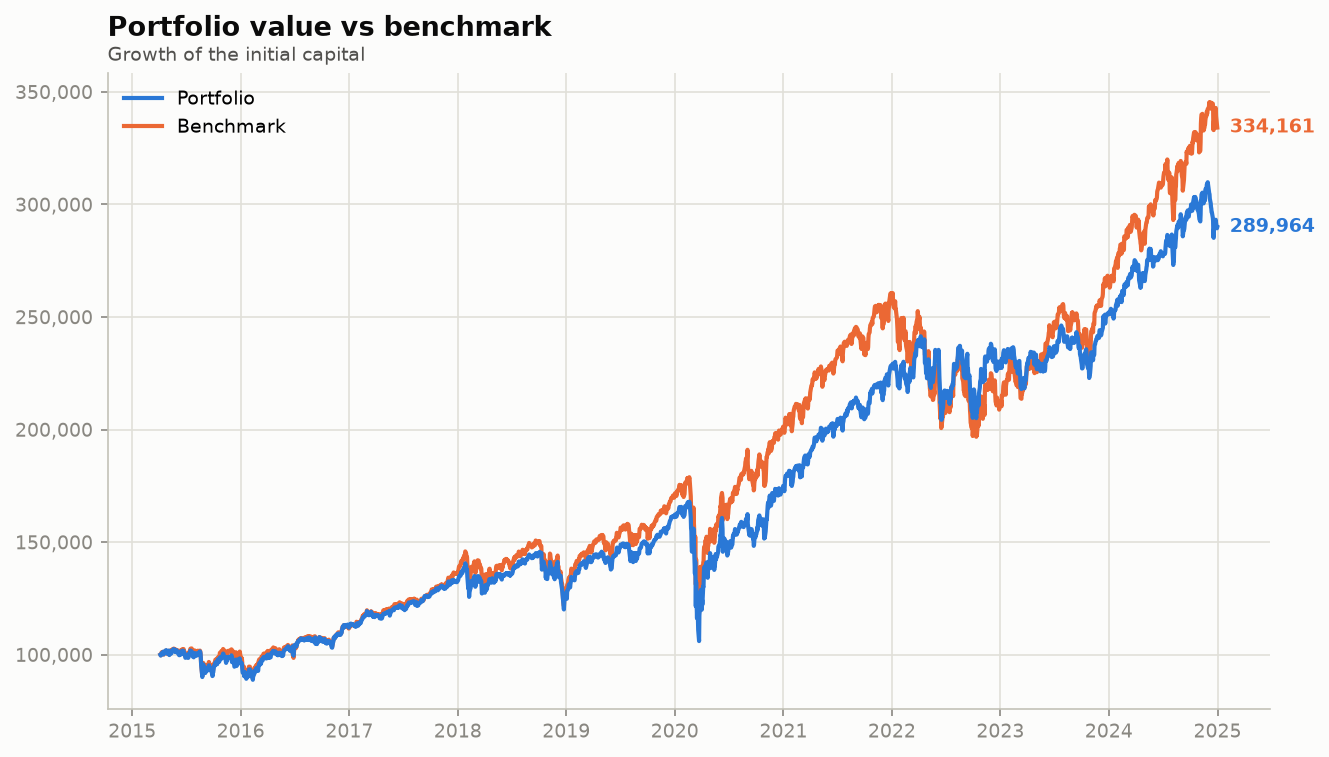

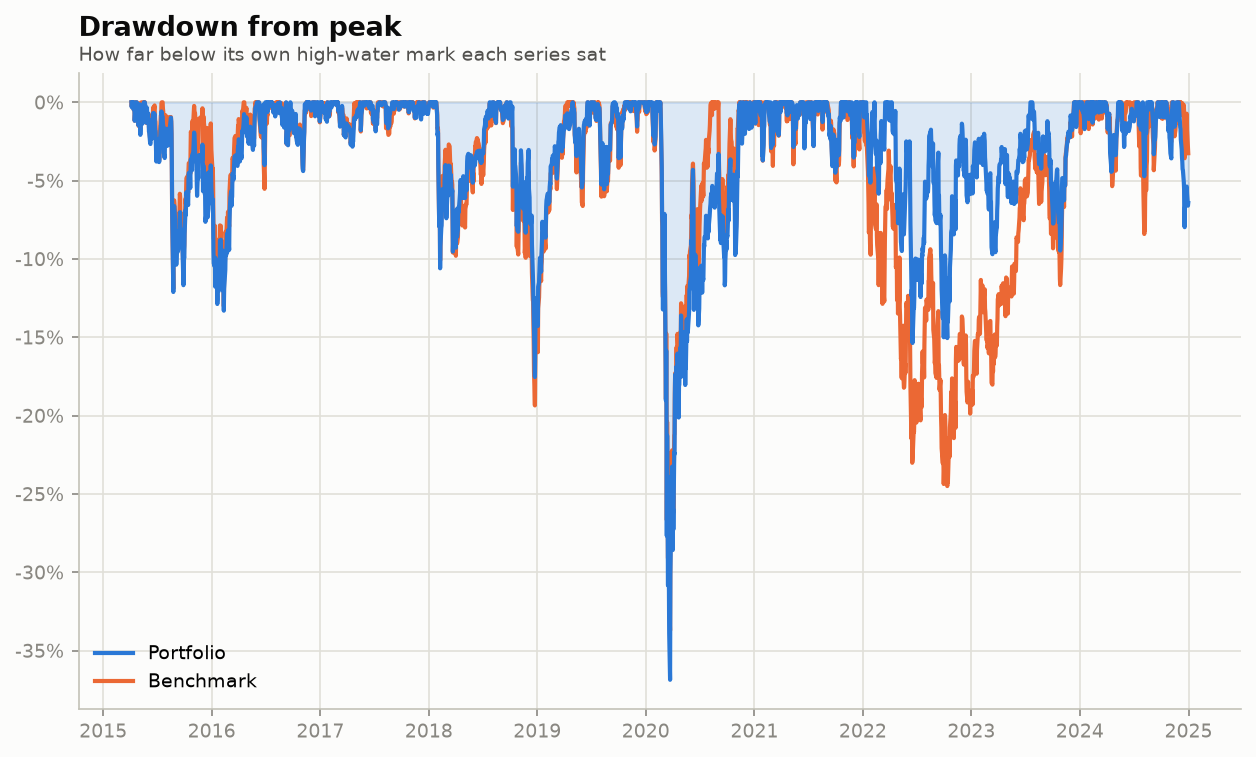

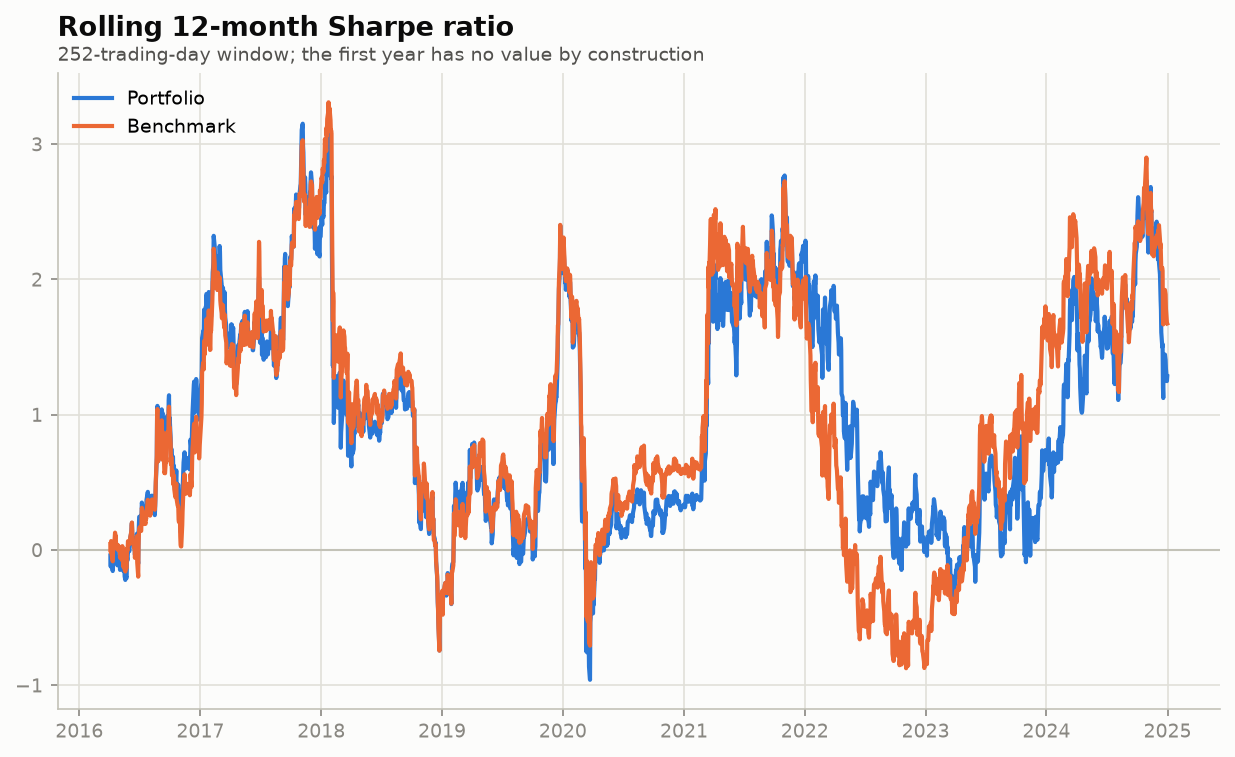

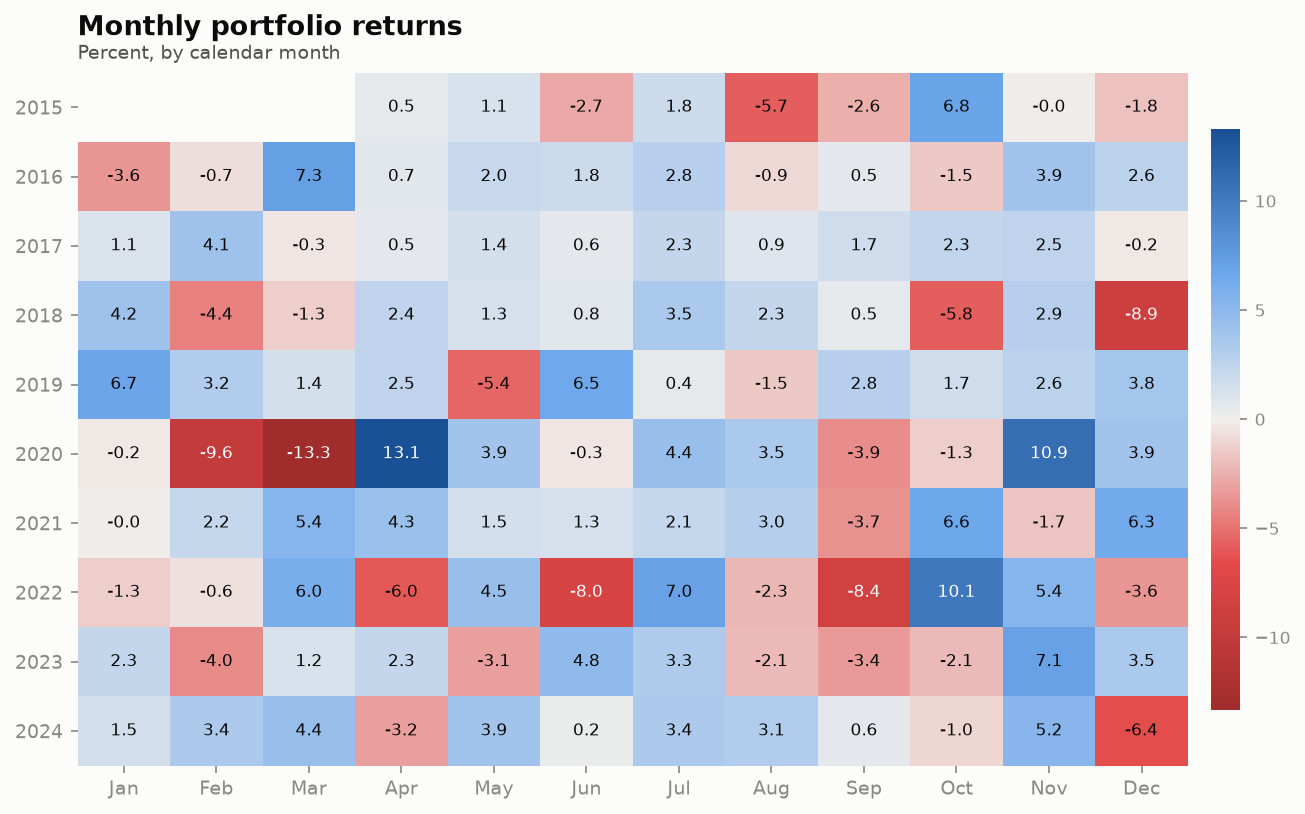

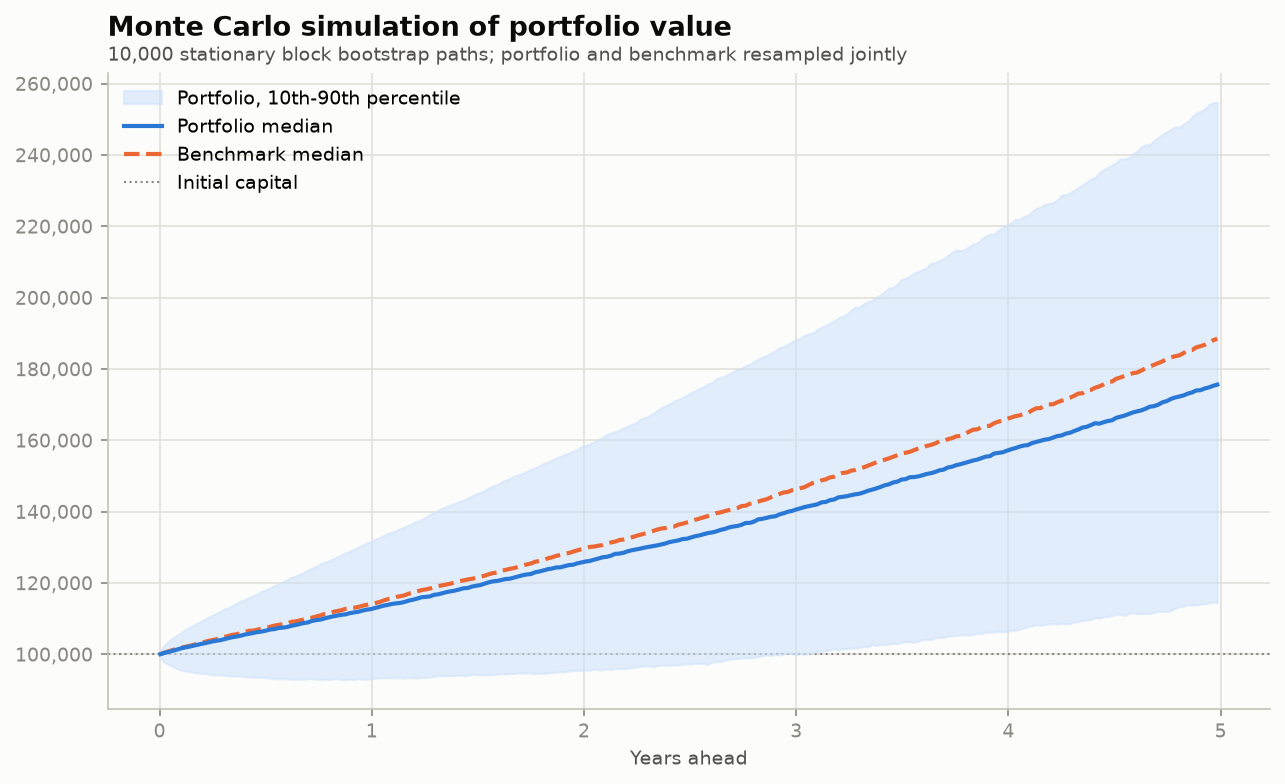

In [8]:
written = plots.generate_all(result, simulation, config.risk_free_rate, OUTPUT_DIR)
for path in written:
    display(Image(filename=str(path)))

## 7. The full report

In [9]:
print(build_report(result, config, comparison, simulation))

                              PORTFOLIO BACKTEST                              
Holdings          XLK, XLF, XLE, XLV, XLU
Benchmark         SPY
Configured window 2015-01-01 to 2024-12-31
Invested window   2015-04-06 to 2024-12-31 (2,453 trading days)
Weighting         inverse_vol (63-day lookback)
Rebalancing       quarterly
Initial capital   100,000.00
Costs             5 bps on turnover
Risk-free rate    2.00% a year
Note              the invested window starts after the configured start because
                  inverse-volatility weighting spends its lookback period estimating
                  the first set of weights.

--- HEADLINE -----------------------------------------------------------------
                                       Portfolio     Benchmark
Final value                              289,964       334,161
Total return                             190.11%       234.16%

--- METRICS ------------------------------------------------------------------
CAGR                

---

## Before reading anything into this

I picked these tickers today, already knowing which of them did well. That inflates
the results and nothing in the engine corrects for it. The cost model also ignores
spread, market impact and slippage, and the benchmark pays no costs at all.

The Known Limitations section of the README has the full list, and it deserves more
attention than the metrics do.